In [1]:

from itertools import combinations
from pathlib import Path
import warnings

import krippendorff
from IPython.display import Markdown, display
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from sklearn.metrics import cohen_kappa_score

EMNLP_RC = {
    "font.family": "serif",
    "font.serif": [
        "Times New Roman", "Times", "Nimbus Roman No9 L",
        "TeX Gyre Termes", "DejaVu Serif",
    ],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}
plt.rcParams.update(EMNLP_RC)
sns.set_theme(style="whitegrid", context="paper", font="serif")

JUDGES = ["anthropic", "google", "openai"]
JUDGE_LABELS = {"anthropic": "Anthropic", "google": "Google", "openai": "OpenAI"}
SCORE_COLS = ["anthropic_score", "google_score", "openai_score"]
MODEL_LABELS = {"gemma2": "Gemma-2B", "gemma2-9b": "Gemma-9B"}

def _darken_rgb(rgb, factor=0.72):
    return tuple(max(0.0, min(1.0, c * factor)) for c in rgb[:3])

def darken_palette(palette, factor=0.72):
    return [_darken_rgb(c, factor) for c in palette]

def darker_cmap(name: str, start: float = 0.35):
    base = plt.colormaps[name]
    return mcolors.LinearSegmentedColormap.from_list(
        f"{name}_dark", base(np.linspace(start, 1.0, 256))
    )

JUDGE_PALETTE_LIST = darken_palette(sns.color_palette("Set2", len(JUDGES)), 0.75)
JUDGE_PALETTE_DISPLAY = {JUDGE_LABELS[j]: JUDGE_PALETTE_LIST[i] for i, j in enumerate(JUDGES)}
MODEL_PALETTE = darken_palette(sns.color_palette("icefire", 2), 0.82)
METRIC_COLORS = ["#1b4f8f", "#8b1e1e"]
ACCENT_COLOR = _darken_rgb(sns.color_palette("Reds", 6)[4], 0.82)
BAR_COLOR = _darken_rgb((0.27, 0.45, 0.77), 0.88)
CMAP_RANK = darker_cmap("YlOrRd").reversed()
CMAP_CORR = darker_cmap("Purples")
CMAP_KAPPA = darker_cmap("Blues")
CMAP_SPEARMAN = darker_cmap("Greens")

TABLE_DIR = Path("inter_rater_t2_results")
TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("figures") / "inter-rater-t2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PDF_SAVE_KW = {
    "bbox_inches": "tight",
    "dpi": 600,
    "facecolor": "white",
}


def save_figure_pdf(stem: str, fig=None, **kwargs):
    fig = fig or plt.gcf()
    save_kwargs = {**PDF_SAVE_KW, **kwargs}
    fig.savefig(FIG_DIR / f"{stem}.pdf", **save_kwargs)


In [2]:

scores = []
temp_2b = pd.read_csv("./main_results/T2-results/inference_t2_annotated_2b.csv")
for _, row in temp_2b.iterrows():
    scores.append({
        "text": row["Gemma2b"],
        "method": "DPO",
        "concept": row["input_concept"],
        "anthropic_score": row["Gemma2b_anthropic_product"],
        "google_score": row["Gemma2b_google_product"],
        "openai_score": row["Gemma2b_openai_product"],
        "model": "gemma2",
    })

temp_9b = pd.read_csv("./main_results/T2-results/inference_t2_annotated_9b.csv")
for _, row in temp_9b.iterrows():
    scores.append({
        "text": row["Gemma9b"],
        "method": "DPO",
        "concept": row["input_concept"],
        "anthropic_score": row["Gemma9b_anthropic_product"],
        "google_score": row["Gemma9b_google_product"],
        "openai_score": row["Gemma9b_openai_product"],
        "model": "gemma2-9b",
    })

scores = pd.DataFrame(scores)
for col in SCORE_COLS:
    scores[col] = pd.to_numeric(scores[col], errors="coerce")

scores["trial"] = scores.groupby(["model", "concept"]).cumcount()
scores["item_id"] = (
    scores["model"] + "::" + scores["concept"] + "::" + scores["trial"].astype(str)
)
scores["unit"] = scores["item_id"]

chunks = []
for judge, col in zip(JUDGES, SCORE_COLS):
    sub = scores[["item_id", "model", "concept", "method", "unit", col]].rename(
        columns={col: "score"}
    )
    sub["judge"] = judge
    chunks.append(sub)
ratings_long = pd.concat(chunks, ignore_index=True)

CONCEPTS = sorted(scores["concept"].unique())
MODELS = sorted(scores["model"].unique())
n_complete = (
    ratings_long.groupby("item_id")["score"]
    .apply(lambda s: s.notna().sum() == len(JUDGES))
    .sum()
)
n_missing_google = int(scores["google_score"].isna().sum())

print(
    f"Loaded {len(scores):,} samples "
    f"({len(MODELS)} models × {len(CONCEPTS)} concepts × 128 trials)"
)
print(f"  Complete triplets (all 3 judges): {n_complete:,} / {len(scores):,}")
print(f"  Missing Google scores: {n_missing_google}")
display(scores.head())


Loaded 2,304 samples (2 models × 9 concepts × 128 trials)
  Complete triplets (all 3 judges): 2,268 / 2,304
  Missing Google scores: 36


,text,method,concept,anthropic_score,google_score,openai_score,model,trial,item_id,unit
0,I think <em>anger</em> is often present in my ...,DPO,Anger,0.44,0.50,0.44,gemma2,0,gemma2::Anger::0,gemma2::Anger::0
1,I think 5.3 is the best car. This ride roars l...,DPO,Anger,0.17,0.38,0.00,gemma2,1,gemma2::Anger::1,gemma2::Anger::1
2,I think <strong>Anger</strong> lies at the hea...,DPO,Anger,0.61,0.50,0.61,gemma2,2,gemma2::Anger::2,gemma2::Anger::2
3,"I think 1stly, anger is a natural emotion that...",DPO,Anger,0.17,0.38,0.07,gemma2,3,gemma2::Anger::3,gemma2::Anger::3
4,"I think <i>I am a powerful being,</i> yet my a...",DPO,Anger,0.44,0.26,0.38,gemma2,4,gemma2::Anger::4,gemma2::Anger::4


In [3]:
openai_by_model_concept = (
    scores.groupby(["model", "concept"], as_index=False)["openai_score"]
    .mean()
    .rename(columns={"openai_score": "openai_mean"})
)
display(openai_by_model_concept.round(2))

,model,concept,openai_mean
0,gemma2,Anger,0.35
1,gemma2,Christian,0.35
2,gemma2,Conspiracy,0.45
3,gemma2,French,0.19
4,gemma2,London,0.60
5,gemma2,Love,0.71
6,gemma2,Praise,0.47
7,gemma2,Want to die,0.28
8,gemma2,Wedding,0.52
9,gemma2-9b,Anger,0.54


In [4]:
(
    scores.groupby("model")["openai_score"]
    .mean()
    .rename(index=MODEL_LABELS)
    .rename("openai_mean")
)

model
Gemma-2B    0.435017
Gemma-9B    0.520122
Name: openai_mean, dtype: float64

In [5]:

def to_ordinal(s: pd.Series, bins: int = 7) -> np.ndarray:
    scaled = np.round(s.to_numpy(dtype=float) * 3)
    return np.clip(scaled, 0, bins - 1).astype(int)

def item_wide(df: pd.DataFrame | None = None) -> pd.DataFrame:
    src = scores if df is None else df
    return src.set_index("unit")[SCORE_COLS].rename(columns=dict(zip(SCORE_COLS, JUDGES)))

def complete_items(long_df: pd.DataFrame) -> pd.DataFrame:
    ok = long_df.groupby("item_id")["score"].apply(
        lambda s: s.notna().sum() == len(JUDGES)
    )
    return long_df[long_df["item_id"].isin(ok[ok].index)]

def krippendorff_alpha_ordinal(wide: pd.DataFrame) -> float:
    reliability = wide[JUDGES].to_numpy().T
    return float(
        krippendorff.alpha(
            reliability_data=reliability,
            level_of_measurement="ordinal",
        )
    )

def icc_3_1(long_subset: pd.DataFrame) -> float:
    data = complete_items(long_subset)[["item_id", "judge", "score"]].copy()
    data["item"] = pd.factorize(data["item_id"].astype(str))[0]
    kwargs = (
        {"nan_policy": "omit"}
        if "nan_policy" in pg.intraclass_corr.__code__.co_varnames
        else {}
    )
    icc = pg.intraclass_corr(
        data=data, targets="item", raters="judge", ratings="score", **kwargs
    )
    for icc_type in ("ICC(C,1)", "ICC3", "ICC(3,1)"):
        row = icc[icc["Type"] == icc_type]
        if not row.empty:
            return float(row["ICC"].iloc[0])
    if "Description" in icc.columns:
        row = icc[
            icc["Description"].str.contains("fixed raters", case=False, na=False)
            & ~icc["Type"].astype(str).str.endswith("k")
        ]
        if not row.empty:
            return float(row["ICC"].iloc[0])
    raise ValueError("ICC(3,1) row not found")

def kendall_w(rank_matrix: pd.DataFrame) -> float:
    ranks = rank_matrix.to_numpy(dtype=float)
    n, k = ranks.shape
    row_sums = ranks.sum(axis=1)
    mean_sum = row_sums.mean()
    s = ((row_sums - mean_sum) ** 2).sum()
    return float(12 * s / (k**2 * (n**3 - n)))

def pairwise_agreement(wide: pd.DataFrame):
    kappa = pd.DataFrame(np.nan, index=JUDGES, columns=JUDGES)
    spearman = pd.DataFrame(np.nan, index=JUDGES, columns=JUDGES)
    for j1, j2 in combinations(JUDGES, 2):
        mask = wide[[j1, j2]].notna().all(axis=1)
        w = wide.loc[mask]
        o1, o2 = to_ordinal(w[j1]), to_ordinal(w[j2])
        k = cohen_kappa_score(o1, o2, weights="quadratic")
        rho, _ = spearmanr(w[j1], w[j2])
        kappa.loc[j1, j2] = kappa.loc[j2, j1] = k
        spearman.loc[j1, j2] = spearman.loc[j2, j1] = rho
    np.fill_diagonal(kappa.values, 1.0)
    np.fill_diagonal(spearman.values, 1.0)
    return kappa, spearman

def fit_mixed_models(long_df: pd.DataFrame):
    rl = long_df.dropna(subset=["score"]).copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m_null = smf.mixedlm("score ~ 1", rl, groups=rl["item_id"]).fit(
            reml=True, method="lbfgs"
        )
        m_judge = smf.mixedlm(
            "score ~ C(judge, Treatment(reference='openai'))",
            rl,
            groups=rl["item_id"],
        ).fit(reml=True, method="lbfgs")
        m_full = smf.mixedlm(
            "score ~ C(model) + C(judge, Treatment(reference='openai')) + C(concept)",
            rl,
            groups=rl["item_id"],
        ).fit(reml=True, method="lbfgs")
    return rl, m_null, m_judge, m_full



# Task 2 inter-rater agreement analysis

Three LLM judges (Anthropic, Google, OpenAI) score **2,304** DPO-steered samples:
**Gemma-2B** and **Gemma-9B** × **9 concepts** × **128 trials**, using the product score
(concept × coherence).

| Analysis | One-line explanation |
|---|---|
| **Krippendorff's α (ordinal)** | Agreement among three judges beyond chance, respecting ordinal scale |
| **ICC(3,1)** | Reliability of a single judge's score for the underlying sample quality |
| **Mixed-effects variance decomposition** | How much variation is due to samples vs judges vs model vs concept |
| **Judge severity (mean & SD)** | Systematic leniency/harshness and scoring-range differences |
| **Kendall's W** | Consistency of concept rankings across judges |
| **Leave-one-judge-out** | Robustness of concept/model conclusions when any judge is removed |



## 1. Reliability — Krippendorff's α and ICC(3,1)

Krippendorff's α treats scores as **ordinal** and natively handles the 36 missing Google scores.
ICC(3,1) uses the two-way mixed, single-rater model on items with complete judge triplets.


Reliability by slice (ordinal α, ICC(3,1)):


,n_items,krippendorff_alpha,icc_3_1
slice,,,
Pooled (all samples),2304,0.726,0.762
Gemma-2B,1152,0.797,0.810
Gemma-9B,1152,0.638,0.695
Anger,256,0.639,0.649
Christian,256,0.781,0.792
Conspiracy,256,0.475,0.617
French,256,0.545,0.479
London,256,0.682,0.845
Love,256,0.450,0.732



Pairwise weighted κ (ordinal bins):


,Anthropic,Google,OpenAI
Anthropic,1.000,0.688,0.783
Google,0.688,1.000,0.655
OpenAI,0.783,0.655,1.000


Pairwise Spearman ρ:


,Anthropic,Google,OpenAI
Anthropic,1.000,0.728,0.839
Google,0.728,1.000,0.713
OpenAI,0.839,0.713,1.000


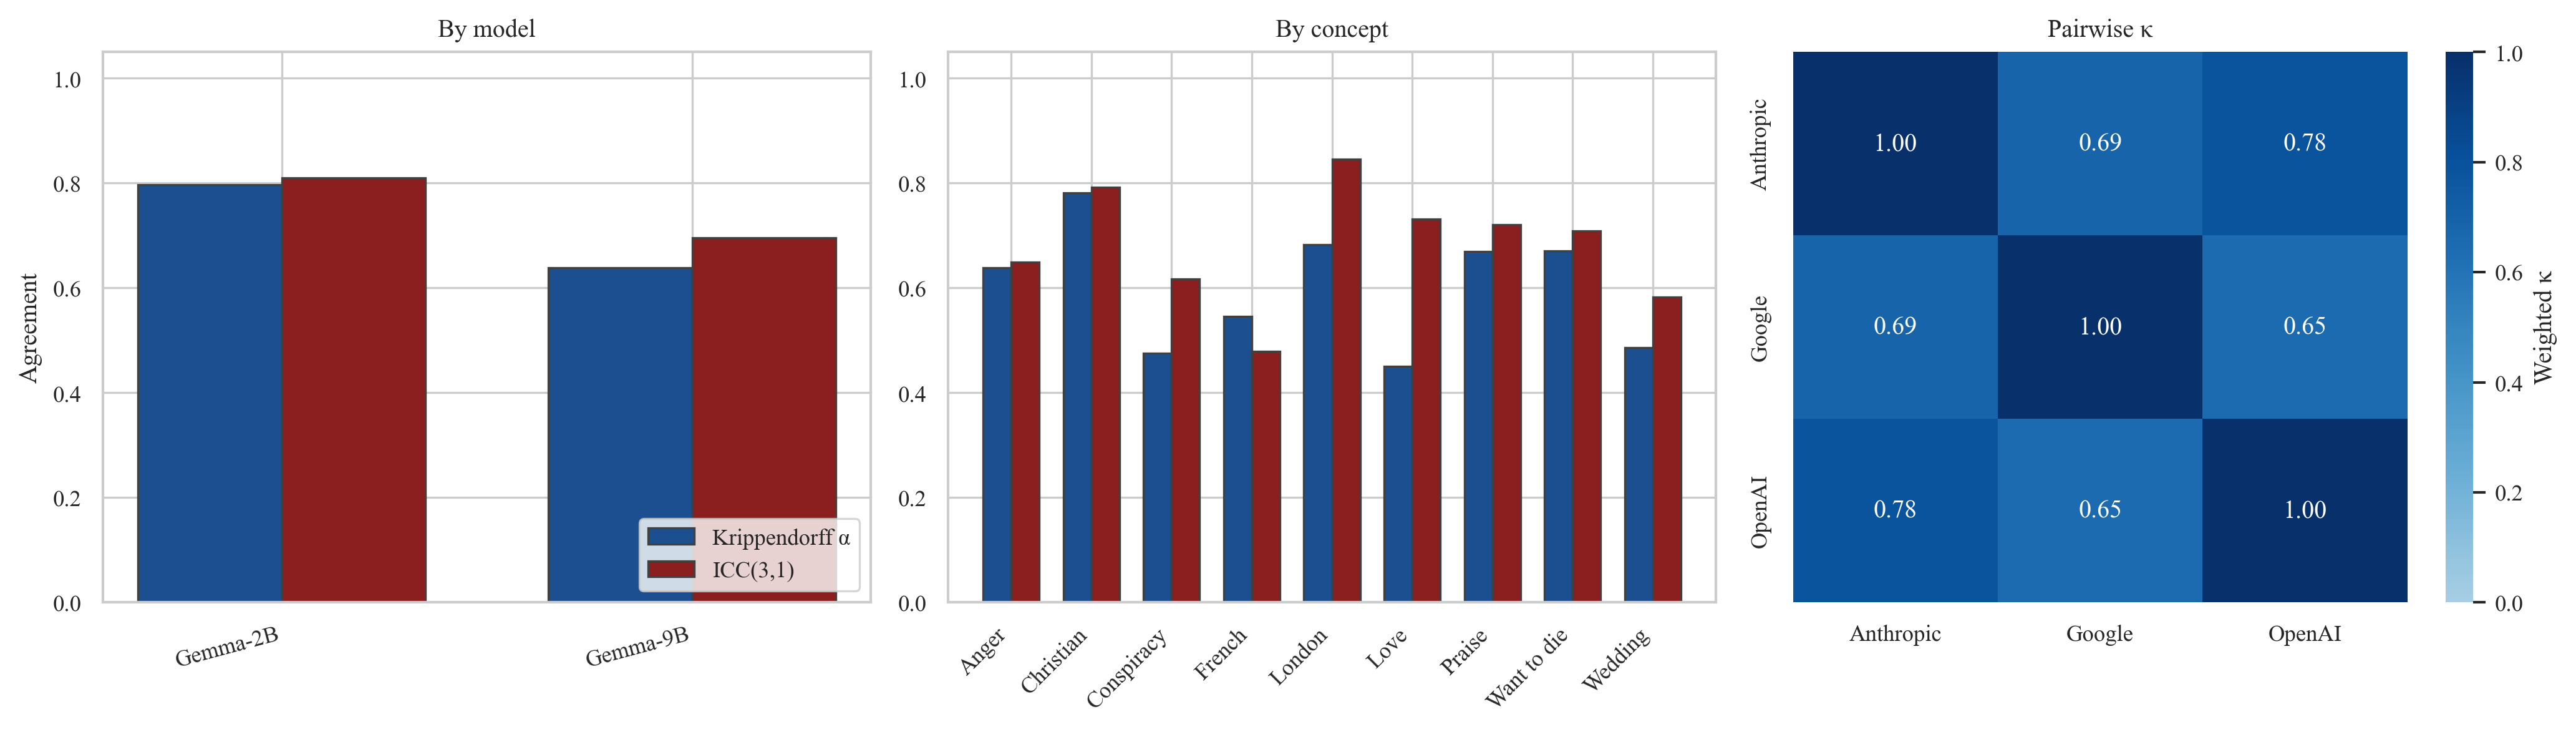

In [6]:

reliability_rows = []
slices = {
    "Pooled (all samples)": scores,
    **{MODEL_LABELS[m]: scores[scores["model"] == m] for m in MODELS},
    **{c: scores[scores["concept"] == c] for c in CONCEPTS},
}

for label, sub in slices.items():
    wide = item_wide(sub)
    long = ratings_long[ratings_long["item_id"].isin(sub["item_id"])]
    reliability_rows.append(
        {
            "slice": label,
            "n_items": len(sub),
            "krippendorff_alpha": krippendorff_alpha_ordinal(wide),
            "icc_3_1": icc_3_1(long),
        }
    )

reliability_df = pd.DataFrame(reliability_rows).set_index("slice")

pooled_wide = item_wide()
pooled_alpha = reliability_df.loc["Pooled (all samples)", "krippendorff_alpha"]
pooled_icc = reliability_df.loc["Pooled (all samples)", "icc_3_1"]

print("Reliability by slice (ordinal α, ICC(3,1)):")
display(reliability_df.round(3))

# Pairwise agreement (pooled)
kappa, spearman = pairwise_agreement(pooled_wide)
kappa.index = kappa.columns = [JUDGE_LABELS[j] for j in JUDGES]
spearman.index = spearman.columns = [JUDGE_LABELS[j] for j in JUDGES]
print("\nPairwise weighted κ (ordinal bins):")
display(kappa.round(3))
print("Pairwise Spearman ρ:")
display(spearman.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

by_model = reliability_df.loc[[MODEL_LABELS[m] for m in MODELS]]
x = np.arange(len(by_model))
w = 0.35
axes[0].bar(x - w / 2, by_model["krippendorff_alpha"], w, label="Krippendorff α", color=METRIC_COLORS[0], edgecolor="0.25")
axes[0].bar(x + w / 2, by_model["icc_3_1"], w, label="ICC(3,1)", color=METRIC_COLORS[1], edgecolor="0.25")
axes[0].set_xticks(x, by_model.index, rotation=15, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Agreement")
axes[0].set_title("By model")
axes[0].legend(loc="lower right")

by_concept = reliability_df.loc[CONCEPTS]
x2 = np.arange(len(by_concept))
axes[1].bar(x2 - w / 2, by_concept["krippendorff_alpha"], w, color=METRIC_COLORS[0], edgecolor="0.25")
axes[1].bar(x2 + w / 2, by_concept["icc_3_1"], w, color=METRIC_COLORS[1], edgecolor="0.25")
axes[1].set_xticks(x2, by_concept.index, rotation=45, ha="right")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("By concept")

sns.heatmap(kappa, annot=True, fmt=".2f", cmap=CMAP_KAPPA, vmin=0, vmax=1, ax=axes[2], cbar_kws={"label": "Weighted κ"})
axes[2].set_title("Pairwise κ")
plt.tight_layout()
save_figure_pdf("fig01_reliability", fig=fig)
plt.show()



## 2. Mixed-effects variance decomposition

We fit a linear mixed model with a **random intercept per sample** and fixed effects for
model, judge (OpenAI reference), and concept. The random-intercept variance captures
between-sample quality; residual variance captures within-sample judge disagreement.


Mixed-model variance components (random intercept + residual):


,component,variance,pct_of_mixed
0,Between-sample (τ² item),0.0354,67.849
1,Within-sample residual (σ²),0.0168,32.151


Item-level ICC (τ² / [τ² + σ²]): 0.678

Marginal spread of group means (% of total score variance):


,factor,variance_of_means,pct_of_total
0,Judge,0.0012,1.6267
1,Model,0.0012,1.6468
2,Concept,0.0175,24.3636



Full mixed model summary:
                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              score    
No. Observations:                6876                 Method:                          REML     
No. Groups:                      2304                 Scale:                           0.0168   
Min. group size:                 2                    Log-Likelihood:                  1970.8947
Max. group size:                 3                    Converged:                       Yes      
Mean group size:                 3.0                                                            
------------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                        

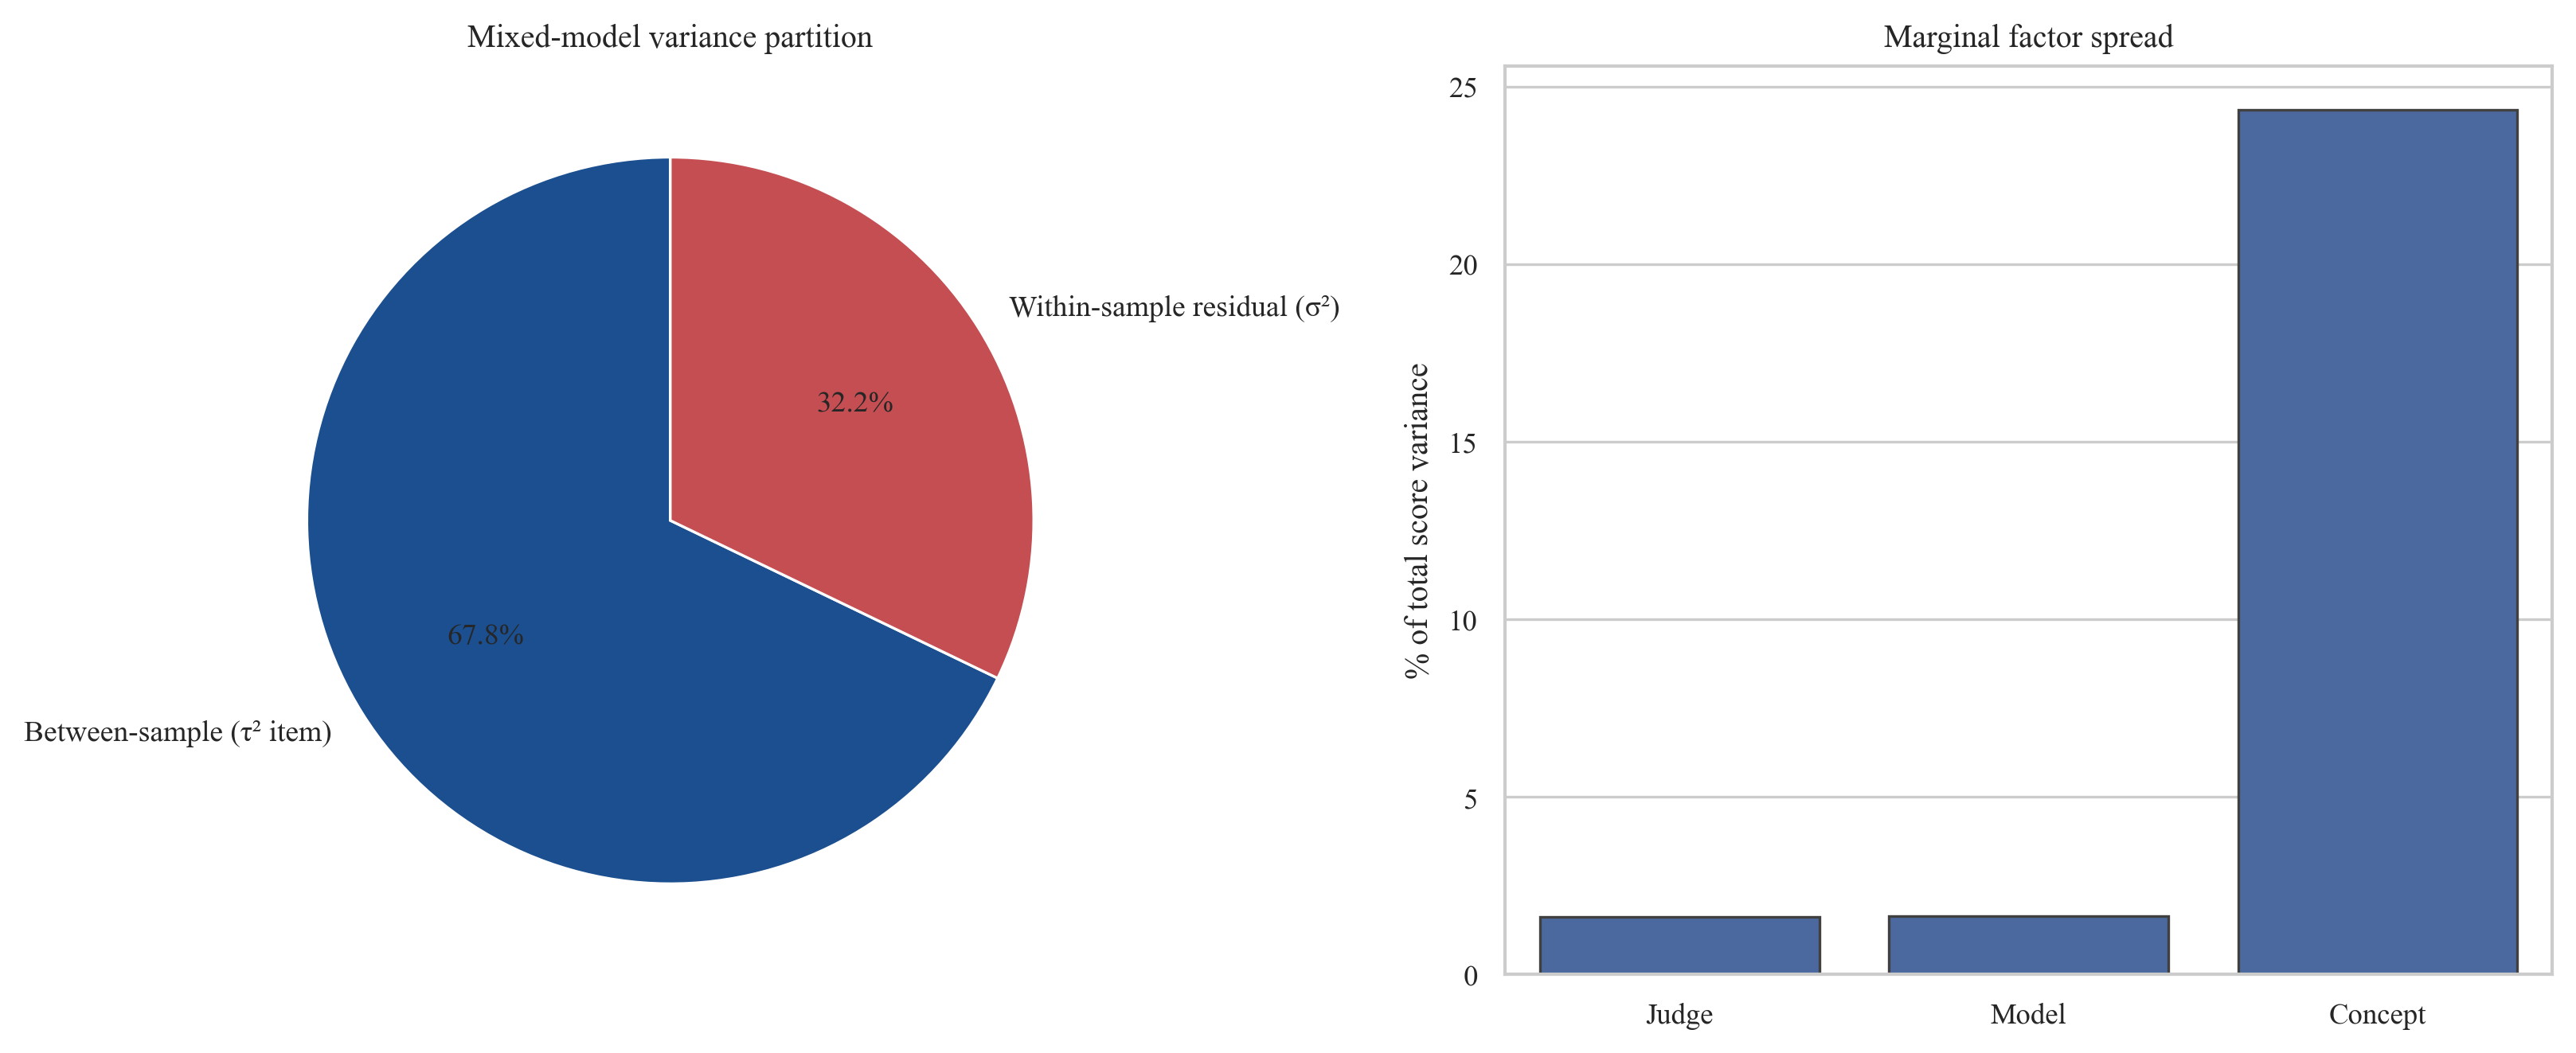

In [7]:

rl, m_null, m_judge, m_full = fit_mixed_models(ratings_long)

tau2_item = float(m_full.cov_re.iloc[0, 0])
sigma2_resid = float(m_full.scale)
total_var = rl["score"].var(ddof=0)
icc_item = tau2_item / (tau2_item + sigma2_resid)

var_components = pd.DataFrame(
    {
        "component": [
            "Between-sample (τ² item)",
            "Within-sample residual (σ²)",
        ],
        "variance": [tau2_item, sigma2_resid],
    }
)
var_components["pct_of_mixed"] = (
    100 * var_components["variance"] / var_components["variance"].sum()
)

# Marginal spread of group means (descriptive, not orthogonal)
marginal = pd.DataFrame(
    {
        "factor": ["Judge", "Model", "Concept"],
        "variance_of_means": [
            rl.groupby("judge")["score"].mean().var(ddof=0),
            rl.groupby("model")["score"].mean().var(ddof=0),
            rl.groupby("concept")["score"].mean().var(ddof=0),
        ],
    }
)
marginal["pct_of_total"] = 100 * marginal["variance_of_means"] / total_var

print("Mixed-model variance components (random intercept + residual):")
display(var_components.round(4))
print(f"Item-level ICC (τ² / [τ² + σ²]): {icc_item:.3f}")
print("\nMarginal spread of group means (% of total score variance):")
display(marginal.round(4))

print("\nFull mixed model summary:")
print(m_full.summary())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

colors = ["#1b4f8f", "#c44e52"]
axes[0].pie(
    var_components["variance"],
    labels=var_components["component"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    textprops={"fontsize": 9},
)
axes[0].set_title("Mixed-model variance partition")

sns.barplot(
    data=marginal,
    x="factor",
    y="pct_of_total",
    ax=axes[1],
    color=BAR_COLOR,
    edgecolor="0.25",
)
axes[1].set_ylabel("% of total score variance")
axes[1].set_xlabel("")
axes[1].set_title("Marginal factor spread")
plt.tight_layout()
save_figure_pdf("fig02_variance_decomposition", fig=fig)
plt.show()



## 3. Judge severity analysis

Compare each judge's **mean** (leniency/harshness) and **SD** (scoring range).
The mixed model reports fixed judge effects relative to OpenAI.


Overall score distribution by judge:


,mean,std,median,count
Anthropic,0.465,0.285,0.520,2304
Google,0.400,0.248,0.445,2268
OpenAI,0.478,0.263,0.520,2304



By model:


metric         mean                     std              
judge     Anthropic Google OpenAI Anthropic Google OpenAI
model                                                    
gemma2        0.427  0.379  0.435     0.301  0.253  0.276
gemma2-9b     0.504  0.421  0.520     0.263  0.241  0.243


By concept (mean scores):


judge,Anthropic,Google,OpenAI
concept,,,
Anger,0.452,0.420,0.445
Christian,0.373,0.394,0.413
Conspiracy,0.497,0.330,0.473
French,0.117,0.178,0.241
London,0.594,0.510,0.598
Love,0.709,0.564,0.725
Praise,0.511,0.468,0.546
Want to die,0.376,0.266,0.359
Wedding,0.556,0.463,0.499


/var/folders/dr/6dv3_zvd16sdmw4zwm1q5rxc0000gp/T/ipykernel_7633/3863758986.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels([JUDGE_LABELS[j] for j in JUDGES])


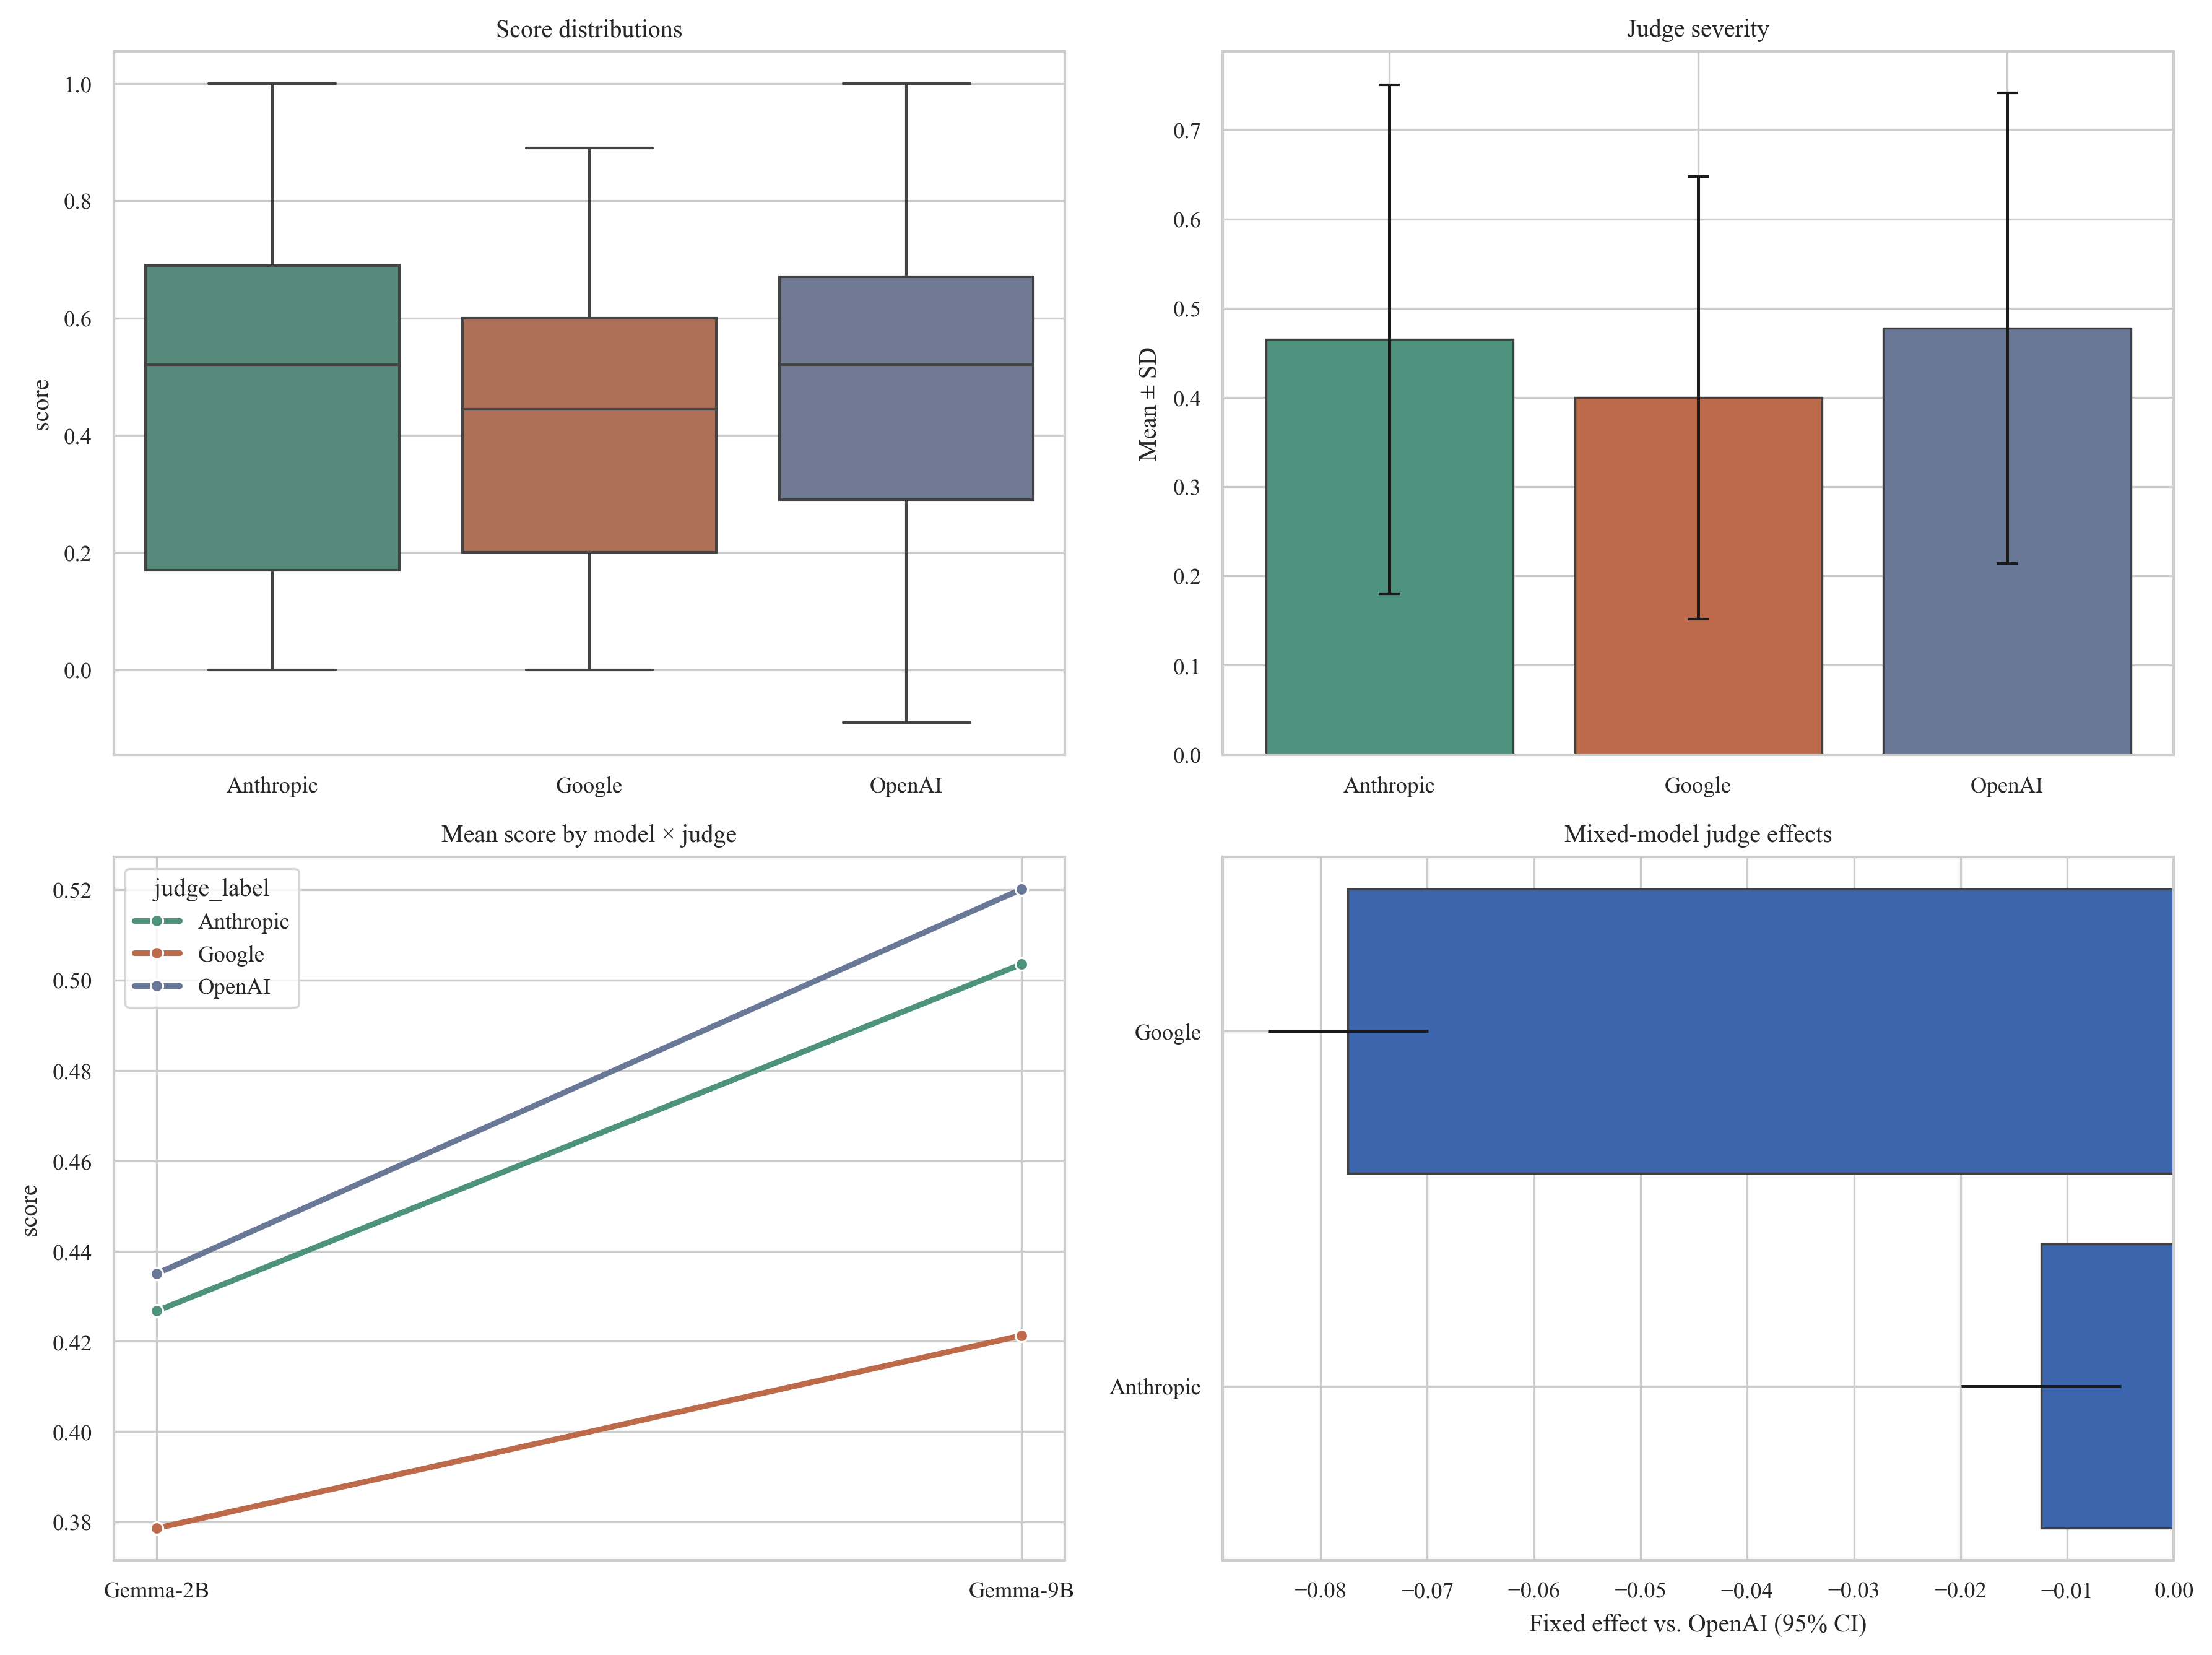

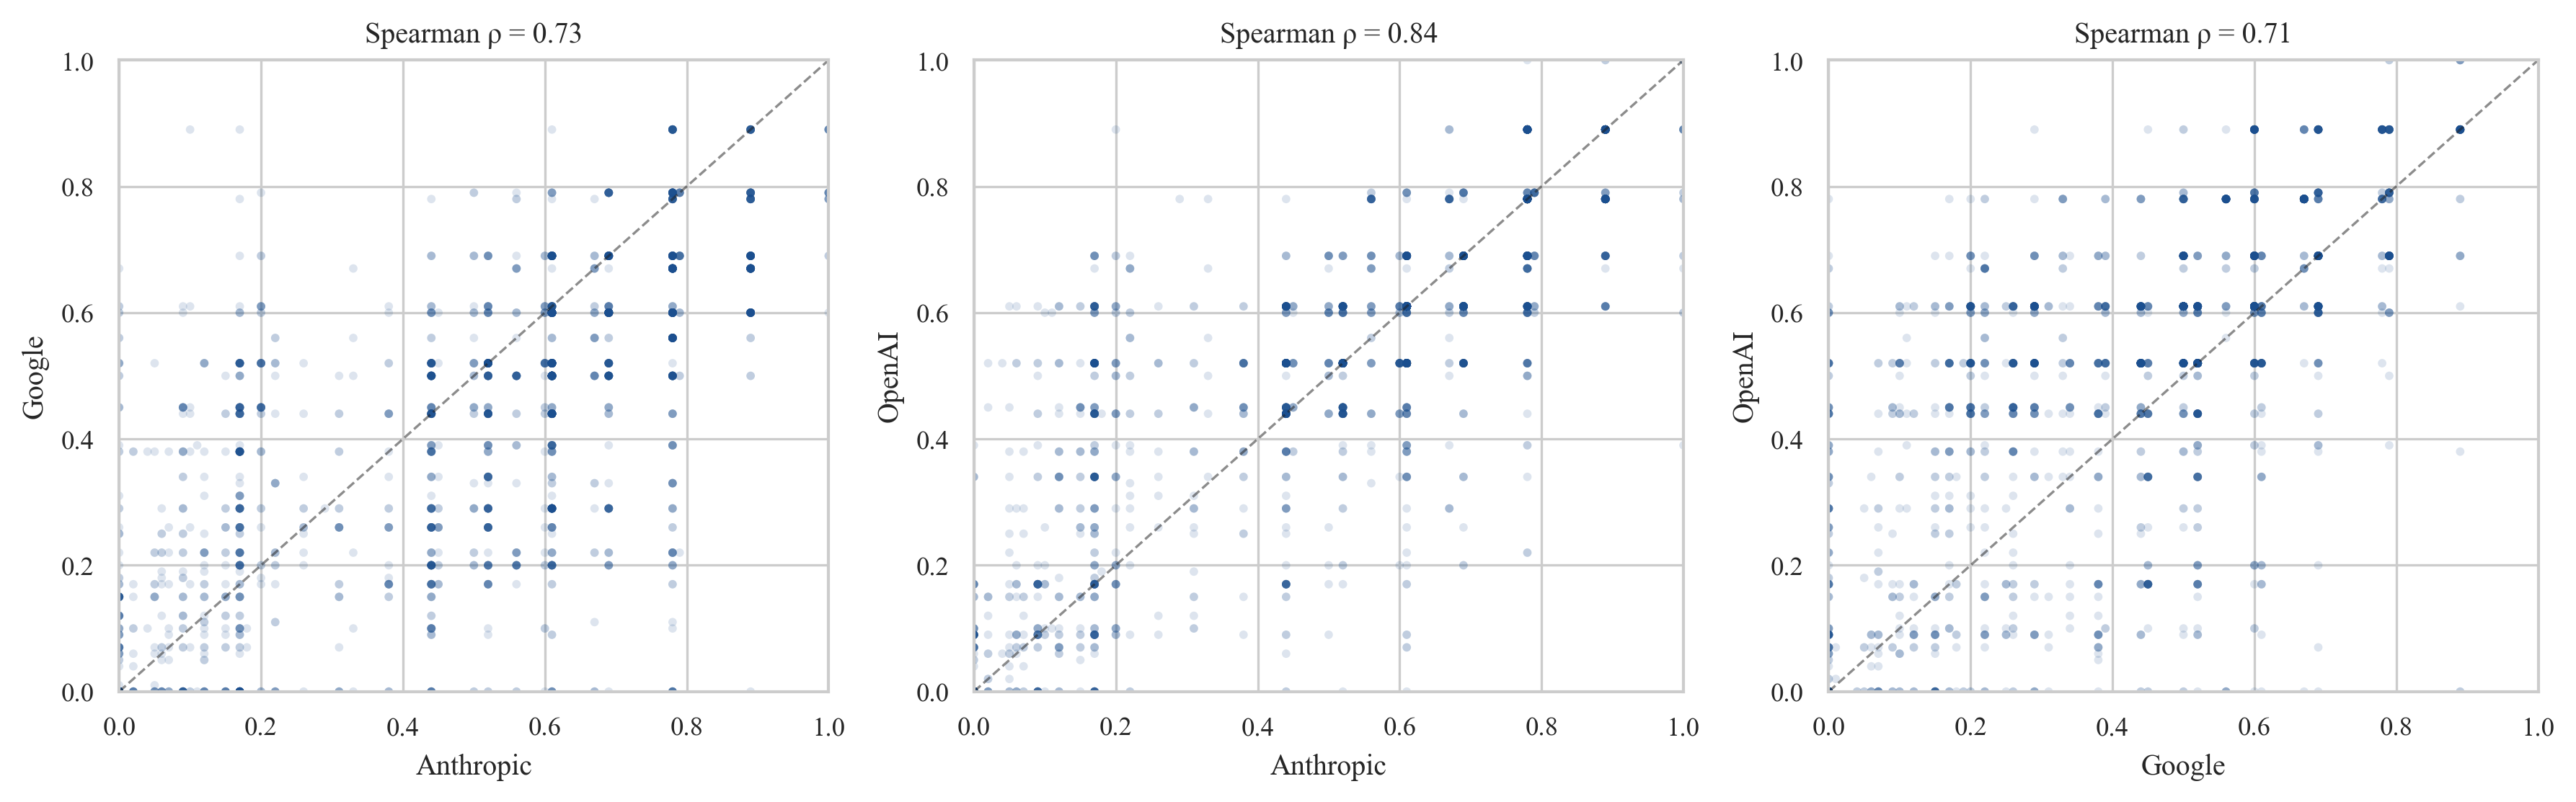

In [8]:

bias_stats = (
    ratings_long.groupby("judge")["score"]
    .agg(mean="mean", std="std", median="median", count="count")
)
bias_stats.index = [JUDGE_LABELS[j] for j in bias_stats.index]

bias_by_model = (
    ratings_long.groupby(["model", "judge"])["score"]
    .agg(mean="mean", std="std")
    .unstack("judge")
)
if isinstance(bias_by_model.columns, pd.MultiIndex):
    bias_by_model.columns = pd.MultiIndex.from_tuples(
        [(m, JUDGE_LABELS[j]) for m, j in bias_by_model.columns],
        names=["metric", "judge"],
    )
else:
    bias_by_model.columns = [JUDGE_LABELS[c] for c in bias_by_model.columns]

bias_by_concept = (
    ratings_long.groupby(["concept", "judge"])["score"]
    .agg(mean="mean", std="std")
    .unstack("judge")
)
if isinstance(bias_by_concept.columns, pd.MultiIndex):
    bias_by_concept.columns = pd.MultiIndex.from_tuples(
        [(m, JUDGE_LABELS[j]) for m, j in bias_by_concept.columns],
        names=["metric", "judge"],
    )
else:
    bias_by_concept.columns = [JUDGE_LABELS[c] for c in bias_by_concept.columns]

print("Overall score distribution by judge:")
display(bias_stats.round(3))
print("\nBy model:")
display(bias_by_model.round(3))
print("\nBy concept (mean scores):")
display(bias_by_concept.xs("mean", axis=1, level=0).round(3) if isinstance(bias_by_concept.columns, pd.MultiIndex) else bias_by_concept.round(3))

judge_effects = m_full.params.filter(like="judge")
judge_se = m_full.bse.filter(like="judge")

def _judge_label(name: str) -> str:
    for j in JUDGES:
        if j in name:
            return JUDGE_LABELS[j]
    return name

judge_effects.index = [_judge_label(n) for n in judge_effects.index]
judge_se.index = judge_effects.index

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.boxplot(
    data=ratings_long,
    x="judge",
    y="score",
    order=JUDGES,
    hue="judge",
    palette=JUDGE_PALETTE_LIST,
    legend=False,
    ax=axes[0, 0],
)
axes[0, 0].set_xticklabels([JUDGE_LABELS[j] for j in JUDGES])
axes[0, 0].set_xlabel("")
axes[0, 0].set_title("Score distributions")

x_pos = np.arange(len(bias_stats))
axes[0, 1].bar(x_pos, bias_stats["mean"], yerr=bias_stats["std"], capsize=4, color=JUDGE_PALETTE_LIST, edgecolor="0.25")
axes[0, 1].set_xticks(x_pos, bias_stats.index)
axes[0, 1].set_ylabel("Mean ± SD")
axes[0, 1].set_title("Judge severity")

means = ratings_long.groupby(["model", "judge"])["score"].mean().reset_index()
means["model_label"] = means["model"].map(MODEL_LABELS)
means["judge_label"] = means["judge"].map(JUDGE_LABELS)
sns.lineplot(
    data=means,
    x="model_label",
    y="score",
    hue="judge_label",
    hue_order=[JUDGE_LABELS[j] for j in JUDGES],
    palette=JUDGE_PALETTE_DISPLAY,
    marker="o",
    linewidth=2.2,
    ax=axes[1, 0],
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_title("Mean score by model × judge")

y_pos = np.arange(len(judge_effects))
axes[1, 1].barh(
    y_pos,
    judge_effects.values,
    xerr=1.96 * judge_se.values,
    color=BAR_COLOR,
    edgecolor="0.25",
)
axes[1, 1].axvline(0, color="black", linewidth=0.8)
axes[1, 1].set_yticks(y_pos, judge_effects.index)
axes[1, 1].set_xlabel("Fixed effect vs. OpenAI (95% CI)")
axes[1, 1].set_title("Mixed-model judge effects")

plt.tight_layout()
save_figure_pdf("fig03_judge_severity", fig=fig)
plt.show()

# Judge scatter matrix (pooled complete cases)
complete_wide = pooled_wide.dropna()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
pairs = list(combinations(JUDGES, 2))
for ax, (j1, j2) in zip(axes, pairs):
    ax.scatter(complete_wide[j1], complete_wide[j2], alpha=0.15, s=8, color="#1b4f8f", edgecolors="none")
    lims = [0, 1]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5)
    rho = spearman.loc[JUDGE_LABELS[j1], JUDGE_LABELS[j2]]
    ax.set_xlabel(JUDGE_LABELS[j1])
    ax.set_ylabel(JUDGE_LABELS[j2])
    ax.set_title(f"Spearman ρ = {rho:.2f}")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
plt.tight_layout()
save_figure_pdf("fig03b_judge_scatter", fig=fig)
plt.show()



## 4. Kendall's W — ranking consistency

### 4a. Concept rankings

Each judge ranks the **9 concepts** by mean score. Kendall's W measures how consistently
the three judges agree on the relative ordering of concepts.


Mean concept scores by judge:


,anthropic,google,openai
concept,,,
Anger,0.452,0.420,0.445
Christian,0.373,0.394,0.413
Conspiracy,0.497,0.330,0.473
French,0.117,0.178,0.241
London,0.594,0.510,0.598
Love,0.709,0.564,0.725
Praise,0.511,0.468,0.546
Want to die,0.376,0.266,0.359
Wedding,0.556,0.463,0.499



Kendall's W (concept rankings, n=9): 0.959


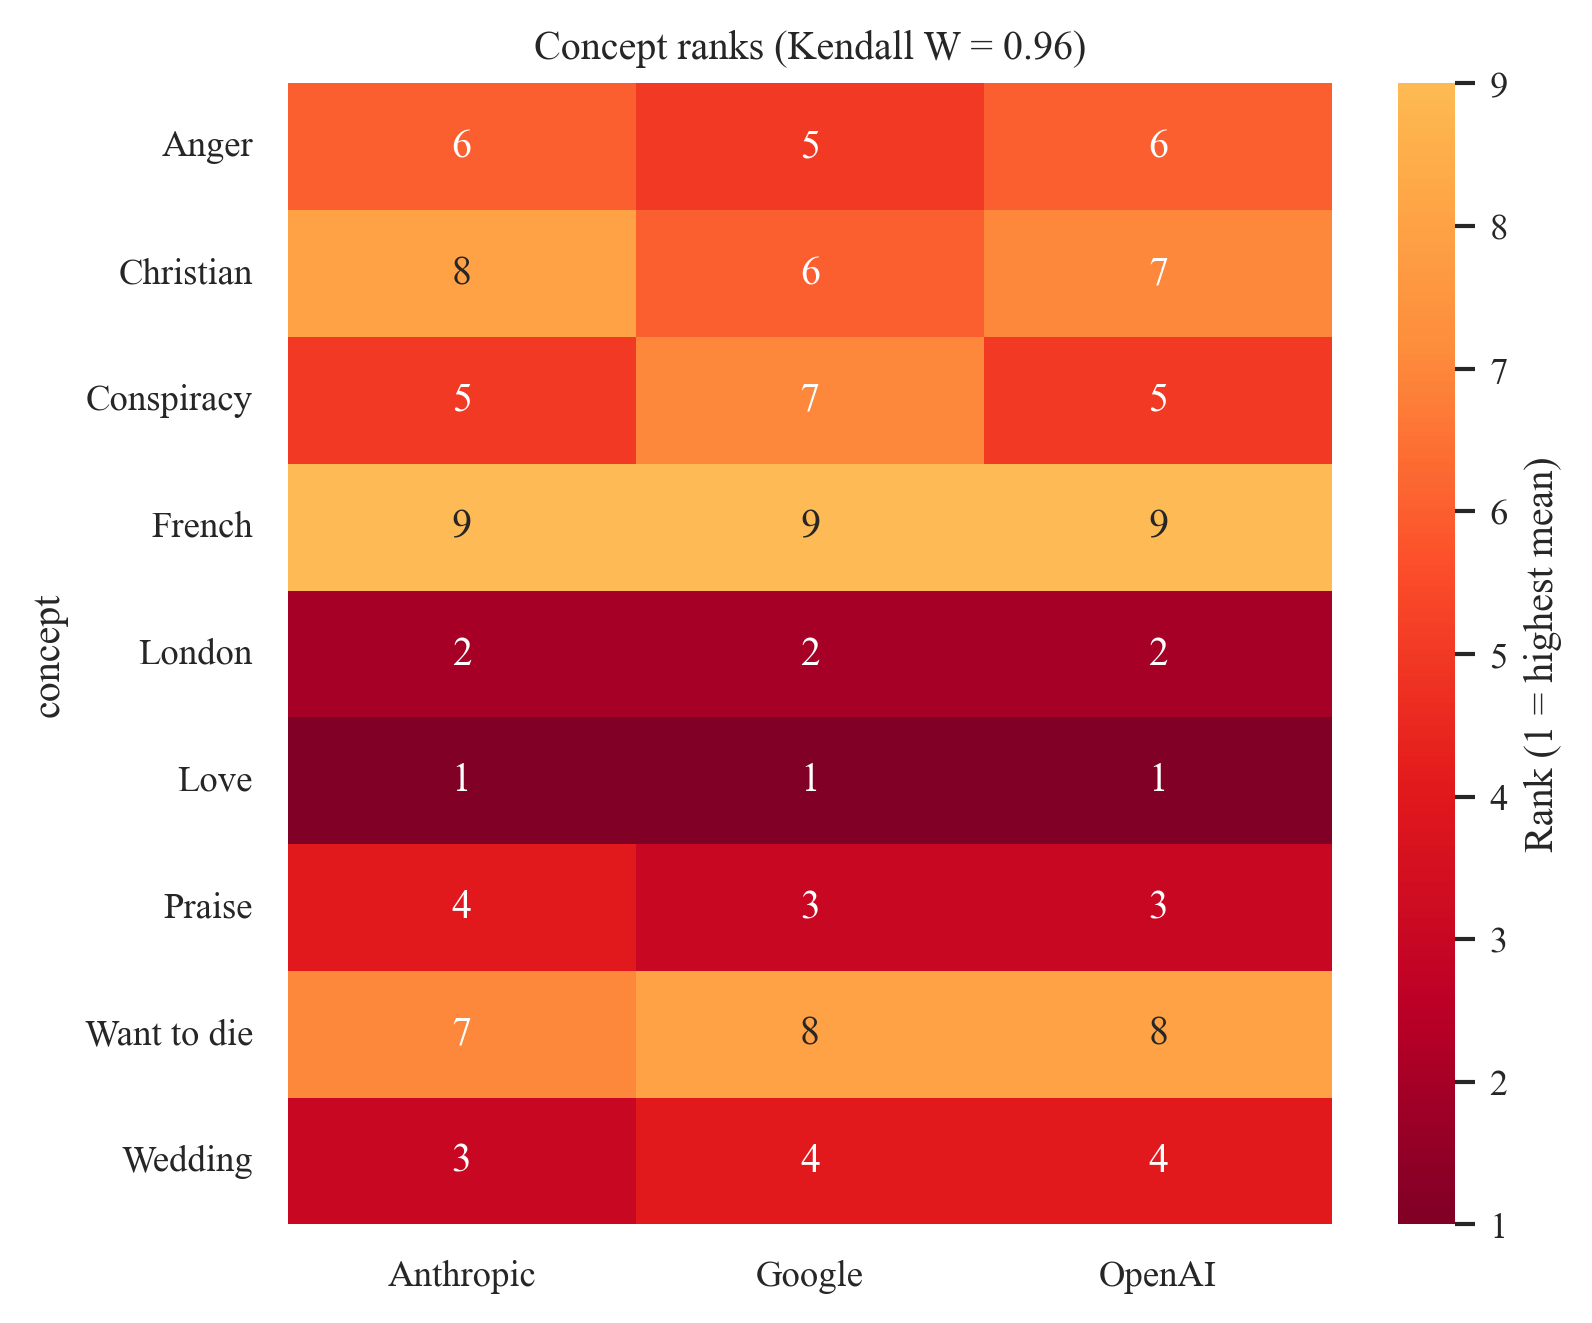

In [9]:

concept_means = pd.DataFrame(
    {
        j: ratings_long[ratings_long["judge"] == j].groupby("concept")["score"].mean()
        for j in JUDGES
    }
)
concept_ranks = concept_means.rank(ascending=False, axis=0)
kendall_w_concepts = kendall_w(concept_ranks)

print("Mean concept scores by judge:")
display(concept_means.round(3))
print(f"\nKendall's W (concept rankings, n=9): {kendall_w_concepts:.3f}")

rank_display = concept_ranks.copy()
rank_display.columns = [JUDGE_LABELS[j] for j in rank_display.columns]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    rank_display,
    annot=True,
    fmt=".0f",
    cmap=CMAP_RANK,
    ax=ax,
    cbar_kws={"label": "Rank (1 = highest mean)"},
)
ax.set_title(f"Concept ranks (Kendall W = {kendall_w_concepts:.2f})")
plt.tight_layout()
save_figure_pdf("fig04a_kendall_w_concepts", fig=fig)
plt.show()


### 4b. Model × concept rankings

We also compute Kendall's W over the **18 model × concept cells**, asking whether the judges
agree on the relative ordering of these finer-grained model/concept combinations.


Kendall's W (model×concept rankings, n=18): 0.939


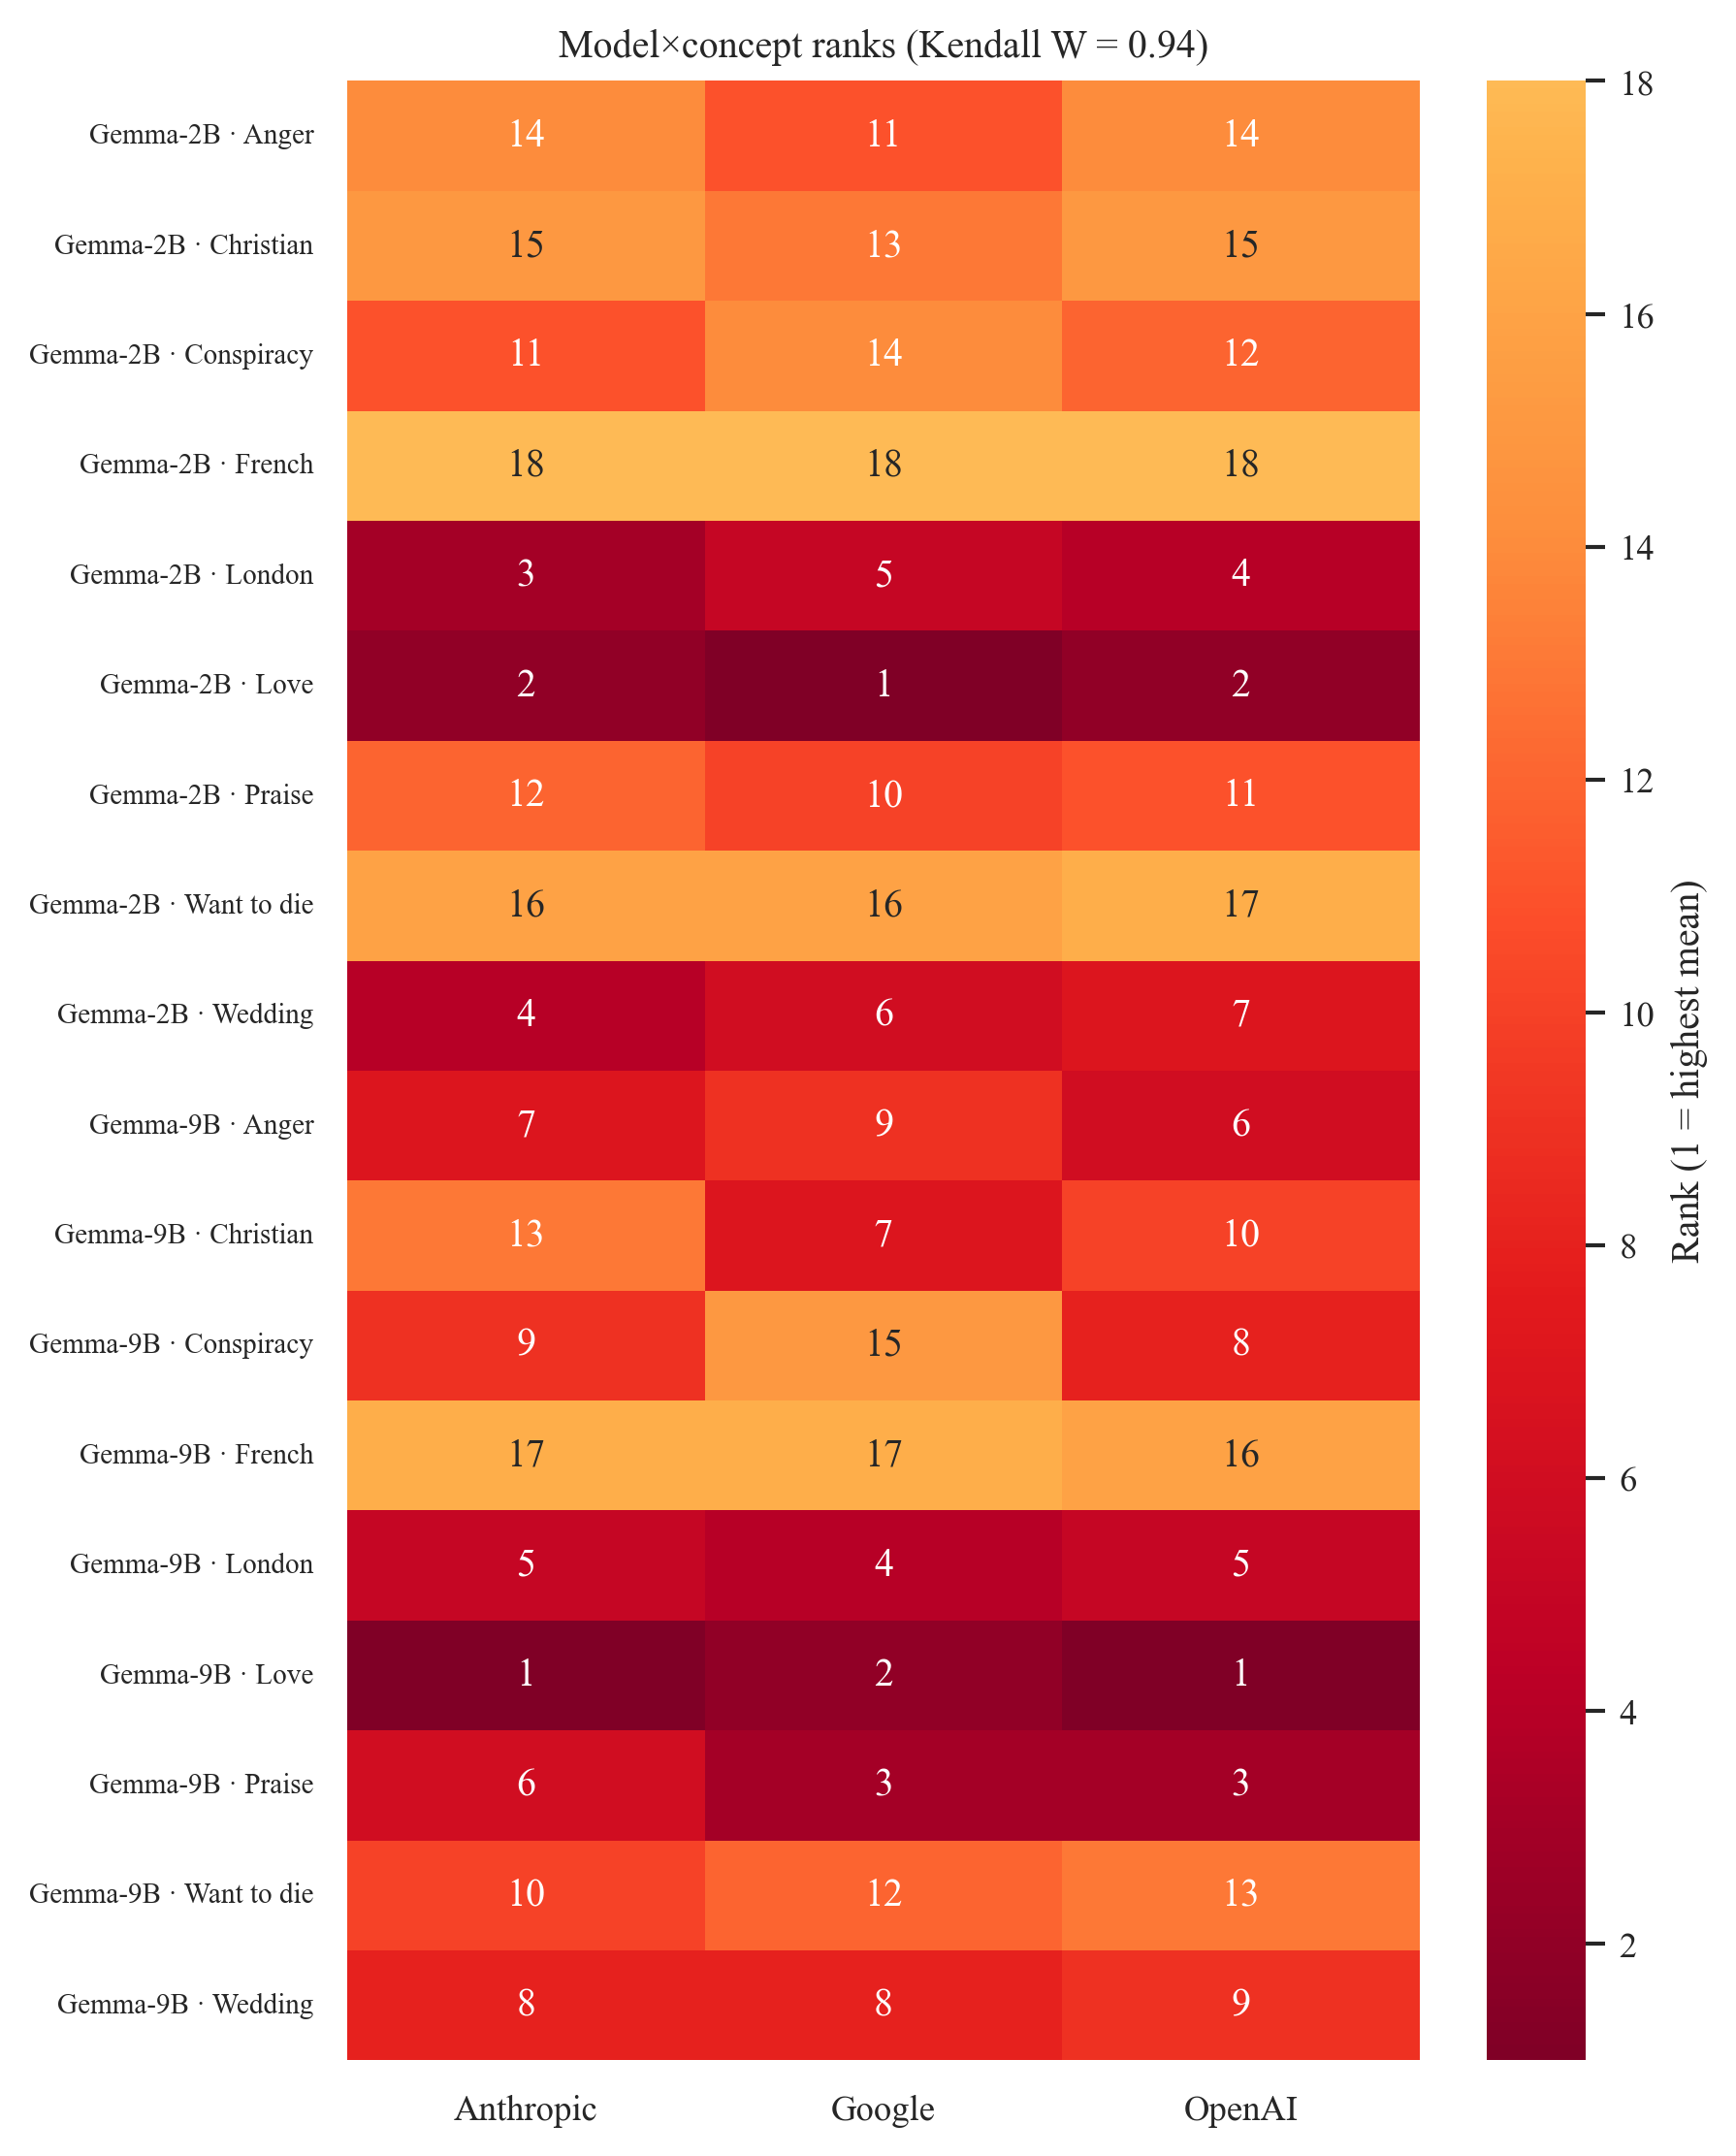

In [10]:
mc_means = (
    ratings_long.groupby(["model", "concept", "judge"])["score"].mean().unstack("judge")
)
mc_ranks = mc_means.rank(ascending=False, axis=0)
kendall_w_mc = kendall_w(mc_ranks)

print(f"Kendall's W (model×concept rankings, n=18): {kendall_w_mc:.3f}")

mc_rank_display = mc_ranks.copy()
mc_rank_display.index = [f"{MODEL_LABELS[m]} · {c}" for m, c in mc_rank_display.index]
mc_rank_display.columns = [JUDGE_LABELS[j] for j in mc_rank_display.columns]
fig, ax = plt.subplots(figsize=(6.0, 7.5))
sns.heatmap(
    mc_rank_display,
    annot=True,
    fmt=".0f",
    cmap=CMAP_RANK,
    ax=ax,
    cbar_kws={"label": "Rank (1 = highest mean)"},
)
ax.set_title(f"Model×concept ranks (Kendall W = {kendall_w_mc:.2f})")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
save_figure_pdf("fig04b_kendall_w_model_concept", fig=fig)
plt.show()
